# Can uncertainty be programmable?

A weather forecast can say that rain has a 40% chance. A normal program can store `0.40`.

These are instances of prescribing a number to probability, which in itself is a means of comprehending uncertainty. 

Instead of Lana can store the uncertainty as a value and apply rules to it.

> **Short answer:** Yes. Lana can represent, combine, measure, transform, and sample uncertainty. Each action has a defined limit.

This article explains the uncertainty model in Lana 1.0. The examples use small Python calculations to make the rules visible. The Python code models the rules; it does not replace the Lana runtime.

## 1. A small Lana example

```lana
state weather = state(p: 0.40, d: 0.20);
state forecast = state(p: 0.70, d: -0.10);
let combined = append(weather, forecast);
let probability = measure combined as probability;
let sample = sample(combined);
```

The two states describe uncertain events. `append` combines them under an independence assumption. `measure` asks for the expected computational-basis probability. `sample` returns one concrete state from the resulting distribution. The original distribution does not change.

## 2. The `STATE` value

Lana represents one concrete state with a two-by-two complex matrix:

$$
\rho = \begin{pmatrix} 1-p & c \\ c^* & p \end{pmatrix}.
$$

`p` is the observable probability of outcome 1 in the computational basis. `c` is an internal complex parameter. A state is valid when:

$$
0 \leq p \leq 1, \qquad |c|^2 \leq p(1-p).
$$

For values between 0 and 1, Lana can store the normalized disposition `d = c / sqrt(p(1-p))`. This gives `|d| <= 1`. At `p = 0` or `p = 1`, Lana sets `d` to zero by convention.

The model is abstract. Lana 1.0 does not claim that every `STATE` is a physical quantum state.

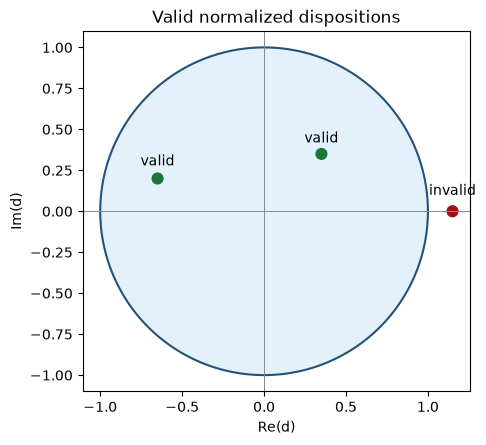

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# The unit disk is the valid region for normalized disposition d.
theta = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(np.cos(theta), np.sin(theta), color="#24527a")
ax.fill(np.cos(theta), np.sin(theta), color="#dceefb", alpha=0.8)
ax.scatter([0.35, -0.65, 1.15], [0.35, 0.20, 0.0], c=["#1b7837", "#1b7837", "#a50f15"], s=60)
ax.axhline(0, color="#888", linewidth=0.7)
ax.axvline(0, color="#888", linewidth=0.7)
ax.set(title="Valid normalized dispositions", xlabel="Re(d)", ylabel="Im(d)", aspect="equal")
ax.text(0.35, 0.42, "valid", ha="center")
ax.text(-0.65, 0.28, "valid", ha="center")
ax.text(1.15, 0.10, "invalid", ha="center")
plt.show()

## 3. What measurement reads

Computational-basis measurement reads `p`:

$$
P(1)=p, \qquad P(0)=1-p.
$$

The internal value `c` does not affect this measurement. This is why two states with the same `p` have the same computational-basis distribution.

Named bases can also read `c`:

| Basis | Probability of the first outcome |
|---|---|
| Computational | `p` |
| `x` | `1/2 + Re(c)` |
| `y` | `1/2 - Im(c)` |

Measurement is read-only. It does not replace or collapse the state. The statement about the diagonal applies to the computational basis, not to every named basis.

In [2]:
p = 0.40
d = 0.20 + 0.10j
c = d * np.sqrt(p * (1 - p))
basis_probabilities = {
    "computational": p,
    "x": 0.5 + c.real,
    "y": 0.5 - c.imag,
}
assert all(0 <= value <= 1 for value in basis_probabilities.values())
basis_probabilities

{'computational': 0.4, 'x': 0.5979795897113271, 'y': 0.45101020514433643}

## 4. Transforming a state

A valid transform maps every valid `STATE` to another valid `STATE`. Lana 1.0 requires the transform to be deterministic, measurable, and validity-preserving.

Valid transforms can be composed. Composition is associative and has an identity transform. A transform does not need to be reversible.

Lana 1.0 includes two registered transforms:

- `INVERT` maps `(p, d)` to `(1-p, conjugate(d))`.
- `NEUTRALIZE` maps `(p, d)` to `(p, 0)`.

These are abstract state operations. They are not claims about physical quantum operations.

## 5. Combining uncertainty with `APPEND`

`APPEND` combines two states as independent binary events. This independence is an assumption made for that operation. Lana does not discover it from the data.

The observable probability is:

$$
p_C = 1-(1-p_A)(1-p_B).
$$

The internal disposition uses:

$$
m_C = \frac{d_A+d_B}{2}, \qquad \sigma_C = \frac{|d_A-d_B|}{2}.
$$

When `sigma_C` is positive, Lana samples `d_C` from a circular normal density truncated to the unit disk and then builds `c_C = d_C sqrt(p_C(1-p_C))`. When `sigma_C` is zero, `d_C` is exactly `m_C`. When `p_C` is 0 or 1, `d_C` is zero.

The observable probability is commutative and associative. The internal distribution is kept as a binary tree, so grouping can change the internal result.

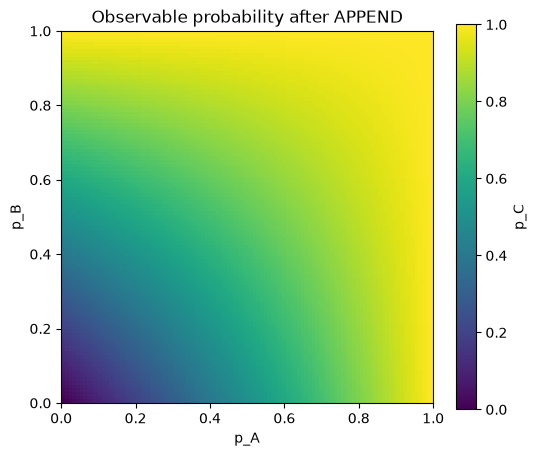

APPEND(0.40, 0.70) = 0.82


In [3]:
# Combine two independent event probabilities with Lana's APPEND rule.
def append_probability(left, right):
    return 1 - (1 - left) * (1 - right)

p_values = np.linspace(0, 1, 101)
left, right = np.meshgrid(p_values, p_values)
combined = append_probability(left, right)
assert np.all((0 <= combined) & (combined <= 1))

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(combined, origin="lower", extent=[0, 1, 0, 1], vmin=0, vmax=1, cmap="viridis")
ax.set(title="Observable probability after APPEND", xlabel="p_A", ylabel="p_B")
fig.colorbar(image, ax=ax, label="p_C")
plt.show()

example = append_probability(0.40, 0.70)
print(f"APPEND(0.40, 0.70) = {example:.2f}")

## 6. Composition and lifting

A normal `STATE` can be embedded as a distribution with probability one. Lana can then apply supported operations to `STATE_DIST` values.

A transform acts on each possible state. This creates a pushforward distribution. A lifted `APPEND` independently draws one state from each input distribution, then applies the ordinary `APPEND` rule.

For computational-basis measurement of a distribution `mu`, the exact probability is the average of the concrete-state probabilities:

$$
P(1)=\int p(\rho)\,d\mu(\rho).
$$

The grouping of a nested `APPEND` expression is meaningful for the internal distribution. Lana must not silently rewrite `APPEND(APPEND(A, B), C)` as `APPEND(A, APPEND(B, C))`.

## 7. Exact values, distributions, and samples

These four ideas are different:

- An exact probability is a mathematical result, such as `0.82`.
- A `STATE_DIST` is a distribution over concrete states.
- A sample is one concrete state selected from that distribution.
- A Monte Carlo estimate averages repeated samples and is approximate.

`sample(dist)` returns one concrete state. The program can bind that state and use it later. Sampling does not mutate `dist`.

For basis-aware probability and distribution measurement of a `STATE_DIST`, Lana 1.0 uses the explicit `estimate_measure` operation. It reports the sample average. More samples generally reduce error, but the operation does not return a confidence interval.

In [4]:
rng = np.random.default_rng(7)
true_probability = 0.70
sample_sizes = [5, 50, 500]
estimates = []
for sample_size in sample_sizes:
    draws = rng.binomial(1, true_probability, size=sample_size)
    estimates.append(draws.mean())

for sample_size, estimate in zip(sample_sizes, estimates):
    print(f"{sample_size:>3} samples: estimate={estimate:.3f}, exact={true_probability:.3f}")

assert all(0 <= estimate <= 1 for estimate in estimates)

  5 samples: estimate=0.600, exact=0.700
 50 samples: estimate=0.760, exact=0.700
500 samples: estimate=0.686, exact=0.700


## 8. The boundary of the model

Lana 1.0 is precise because it is limited.

- `STATE` has a fixed two-dimensional representation.
- `APPEND` uses an explicit independence assumption. It does not infer correlations.
- `STATE` is abstract. It does not automatically mean a physical quantum system.
- Unsupported type combinations and unsupported exact operations return errors.
- Floating-point tolerance handles machine precision. It does not extend the mathematical domain.
- Lazy distributions defer evaluation. They do not enumerate every possible state.

This is the important safety property: Lana does not silently turn an unknown result into a definite result.

In [5]:
# Check the two mathematical conditions that define a valid state.
def valid_state(p, c):
    return 0 <= p <= 1 and abs(c) ** 2 <= p * (1 - p)

assert valid_state(0.4, 0.2)
assert not valid_state(0.4, 0.6)
assert append_probability(0.0, 0.0) == 0.0
assert append_probability(1.0, 0.0) == 1.0
print("Boundary checks passed.")

Boundary checks passed.


## 9. The answer

Uncertainty is programmable when a program can represent it, preserve it, combine it, and report what it does not know.

Lana 1.0 does this for a small, explicit state model. It defines values, operations, validation rules, and failure behavior. Its strength is not that it removes uncertainty. Its strength is that it prevents the program from hiding uncertainty.